# Factor Analysis and Diagnostics

## Purpose

A **factor** (aka **signal**) is a vector $f_t \in \mathbb{R}^{N_t}$. We have one score per stock, assigned at each date $t$. The central question of this notebook is:

> does the direction of $f_t$ predict the direction of next month's return vector $r_{t+1}$?

In linear-algebraic terms, this is a question about the **angle** between two vectors. If $f_t$ and $r_{t+1}$ point in similar directions (small angle, high cosine similarity), the factor has predictive power. If they're nearly orthogonal, it doesn't. 

We test four standard cross-sectional factors, most of which we compute as priced-based proxies since we are using pretty basic data. They are momentum, value, quality, and low volatility.

> **Spoiler**: Momentum wins, and the rest have negative or insignificant information coefficients over this period. The methodology for diagnosing a factor is the same whether it works or not, and showing *why* the proxies fail is more instructive than silently dropping them.

The main goals of this notebook are.
1. To define and compute four cross-sectional factors (momentum, value, quality, low-vol) as vectors $f_t$.
2. To measure each factor's information coefficient (**IC**) — the cosine similarity between $f_t$ and $r_{t+1}$.
3. To examine **IC stability** across subperiods (walk-forward: is the factor consistent, or just lucky in one period?).
4. To examine IC decay at longer periods.
5. To quantify **turnover** via rank autocorrelation.
6. To check **cross-factor correlations** (the Gram matrix).

## Terms used

| Term | Meaning |
|------|---------|
| **Factor / signal** | A vector $f_t \in \mathbb{R}^{N_t}$ assigning a score to each stock at date $t$ |
| **Momentum** | Trailing 12-month return skipping the last month; "winners keep winning" |
| **Value** | Cheap stocks (low price vs. fundamentals) may outperform; proxied here by inverse long-term return |
| **Quality** | Profitable/stable firms may outperform; proxied by a return Sharpe ratio |
| **Low volatility** | Low-risk stocks may outperform on a risk-adjusted basis |
| **Information coefficient (IC)** | Spearman rank correlation between $f_t$ and $r_{t+1}$ — cosine similarity of rank vectors |
| **Information ratio (IR)** | Mean IC / std(IC) — a signal-to-noise ratio for the factor |
| **Sharpe ratio** ↻ | Mean return / volatility — used as the quality-factor proxy (12m Sharpe-like ratio) |
| **Rank** | A permutation of $\{1,\dots,N\}$; makes factors comparable and robust to outliers |
| **Turnover (proxy)** | How much the signal changes; proxied here by rank autocorrelation |
| **Walk-forward** | Split into sub-windows and test IC stability across regimes |
| **Return panel** $\mathbf{R}$ ↻ | The return matrix whose rows (cross-sections) we rank |
| **Cross-section** ↻ | All stocks at one date — we rank within each row |

## Outputs

This notebook produces per-factor IC time series, subperiod IC stability tables, decay curves, turnover estimates, and a correlation matrix (the Gram matrix of factor vectors). These feed directly into constructions in later notebooks.

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Load Data](#load-data)
3. [Factor Definitions](#factor-definitions)
4. [Information Coefficient Analysis](#information-coefficient-analysis)
5. [Subperiod IC Stability (Walk-Forward)](#subperiod-ic-stability-walk-forward)
6. [Factor Decay](#factor-decay)
7. [Turnover via Rank Autocorrelation](#turnover-via-rank-autocorrelation)
8. [Cross-Factor Correlations](#cross-factor-correlations)
9. [Conclusion](#conclusion)

## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/02_factor_diagnostics', exist_ok=True)

RANDOM_STATE = 3

In [3]:
"""
==================================
Load return panel and sector mapping
==================================
"""
df_returns = pd.read_csv('../data/processed/returns_monthly.csv', index_col=0, parse_dates=True)
df_prices = pd.read_csv('../data/processed/prices_monthly.csv', index_col=0, parse_dates=True)
df_sector = pd.read_csv('../data/processed/sector_mapping.csv')

print(f"Returns: {df_returns.shape}")
print(f"Prices: {df_prices.shape}")
print(f"Sectors: {len(df_sector)}")

Returns: (251, 501)
Prices: (252, 503)
Sectors: 503


## Factor definitions
We'll now compute are four standard factors. All are cross-sectional ranks (permutations) at each month-end, so they live on the same scale and can be combined later without further normalization.

- **Momemtum**: Trailing 12-month return skipping the most recent month ($t - 12$ to $t - 2$). The intuition behind is that stocks that went up over the past year tend to keep going up for another month or two
- **Values**: we use price-based inverse momentum as a value proxy: 60-month trailing return, inverted. The intuition is that stocks that went down over 5 years are "cheap" and may mean-revert.
- **Quality**: 12-month Sharpe-like ratio of monthly returns (mean / std). The intuition is that stocks with smooth positive returns are "higher quality".
- **Low-volatility**: Inverse of 60-month trailing volatility, ranked. Intuition is that low-risk stocks tend to outperform on a risk-adjusted basis.


The following code builds four factor matrices, each matching the shape of `df_returns`, where every cell holds a cross-sectional rank in $[-0.5, 0.5]$. The helper function converts any raw signal to percentile ranks centered at zero. Applied with `axis=1` so ranking happens across stocks within each month, not down time.

**The output:**
A dict `factor_dict` holding four DataFrames, plus a print loop confirming shapes and non-null month counts. Momentum needs ~12 months of history; value and low-vol need ~60; quality needs ~12.

**Key caveat:** Momentum is the only academically faithful signal. Value, quality, and low-vol are price-based proxies — useful for learning the methodology, but expect weak or negative ICs because the proxies conflate the true factors with mean-reversion and volatility effects.

In [8]:
"""
==================================
Compute factor exposures
==================================
"""
def cross_sectional_rank(series):
    """Rank cross-sectionally, scaled to [-0.5,0.5]"""
    return series.rank(pct=True) - 0.5

# Momentum (12-1): sum of returns from t-12 to t-2
mom_12_1 = df_returns.rolling(11).sum().shift(1)
df_momentum = mom_12_1.apply(cross_sectional_rank, axis=1)

# Value (proxy): inverse 60-month momentum
mom_60 = df_returns.rolling(60).sum().shift(1)
df_value = (-mom_60).apply(cross_sectional_rank, axis=1)

# Quality (proxy): 12m sharpe-like
mean_12 = df_returns.rolling(12).mean().shift(1)
std_12 = df_returns.rolling(12).std().shift(1)
quality_raw = mean_12 / std_12.replace(0, np.nan)
df_quality = quality_raw.apply(cross_sectional_rank, axis=1)

# Low volatility: inverse 60m vol
vol_60 = df_returns.rolling(60).std().shift(1)
df_lowvol = (-vol_60).apply(cross_sectional_rank, axis=1)


factor_dict = {
    'momentum': df_momentum,
    'value': df_value,
    'quality': df_quality,
    'lowvol': df_lowvol,
}

for name, df_f in factor_dict.items():
    print(f"{name}: {df_f.shape}, non-null months: {df_f.notna().any(axis=1).sum()}")

momentum: (251, 501), non-null months: 240
value: (251, 501), non-null months: 191
quality: (251, 501), non-null months: 239
lowvol: (251, 501), non-null months: 191


## Information Coefficient Analysis

The **information coefficient (IC)** at date $t$ is the Spearman rank correlation between the factor vector $f_t$ and the realized return vector $r_{t+1}$. From the linear algebraic perspective, this is just the Pearson correlation applied to rank vectors. For two centered vectors $u,v$, this is the cosine of the angle between them:
$$ \rho(u,v) = \frac{\langle u,v \rangle}{\|u\|\|v\|} = \cos\theta. $$
So the IC is $\cos\theta$, where $\theta$ is the angle between the factor rank vector and the return rank vector. An IC of 1 means perfect alignment (zero angle); IC of 0 means orthogonality (no predictive power); IC of -1 means anti-alignment. 

The **information ratio (IR)** is the mean IC divided by the standard deviation of IC across dates: 
$$ \text{IR} = \frac{\text{Mean IC}}{\text{Std IC}} \times \sqrt{12}. $$
This is a ration of signal and noise, which tells us whether the factor reliably predicts returns or is just noise.

In [ ]:
"""
==================================
Compute monthly IC (Spearman rank correlation)
==================================
"""
from scipy.stats import spearmanr

def compute_monthly_ic(factor_df, return_df):
    """Compute Spearman IC between factor and next-month returns."""
    common_dates = factor_df.index.intersection(return_df.index)
    common_tickers = factor_df.columns.intersection(return_df.columns)

    ic_series = []
    for date in common_dates:
        f = factor_df.loc[date, common_tickers]
        r = return_df.loc[date, common_tickers]

        mask = f.notna() & r.notna()
        if mask.sum() < 20: # sample size filter
            ic_series.append(np.nan)
            continue
        
        ic, _ = spearmanr(f[mask], r[mask])
        ic_series.append(ic)
    return pd.Series(ic_series, index=common_dates)

ic_results = {}
for name, df_f in factor_dict.items():
    print(f"Computing IC for {name}... ")
    ic_results[name] = compute_monthly_ic(df_f,df_returns)

df_ic = pd.DataFrame(ic_results)
df_ic = df_ic.dropna(how='all')

print("\nIC Summary\n")
ic_summary = df_ic.describe().T[['mean', 'std', 'min', 'max']]
ic_summary['ic_ir'] = ic_summary['mean']/ic_summary['std'] * np.sqrt(12)
display(ic_summary.round(4))

Computing IC for momentum... 
Computing IC for value... 
Computing IC for quality... 
Computing IC for lowvol... 

IC Summary



,mean,std,min,max,ic_ir
momentum,0.0060,0.1905,-0.6011,0.4032,0.1091
value,-0.0216,0.1576,-0.3878,0.6297,-0.4750
quality,-0.0025,0.1945,-0.5120,0.4798,-0.0448
lowvol,-0.0259,0.2360,-0.5288,0.5478,-0.3808


Note that added a sample size filter with `mask.sum() < 20`. The `mask` identifies stocks that have both a valid factor score and a valid forward return in a given month, and `mask.sum()` counts how many usable pairs you actually have. The `< 20` threshold prevents the code from computing a correlation on a tiny sample, which is statistically meaningless and numerically unstable (e.g., Spearman correlation on 2 stocks is always exactly ±1). If you don't gate this, early-history months, mass delistings, or data gaps inject garbage ±1.0 values into your IC time series, which then contaminate every downstream statistic like the mean IC, Information Ratio, and decay curves. Setting a floor of 20 filters out those degenerate months while retaining enough valid data to produce a reliable signal.

We do this sort of masking throughout.

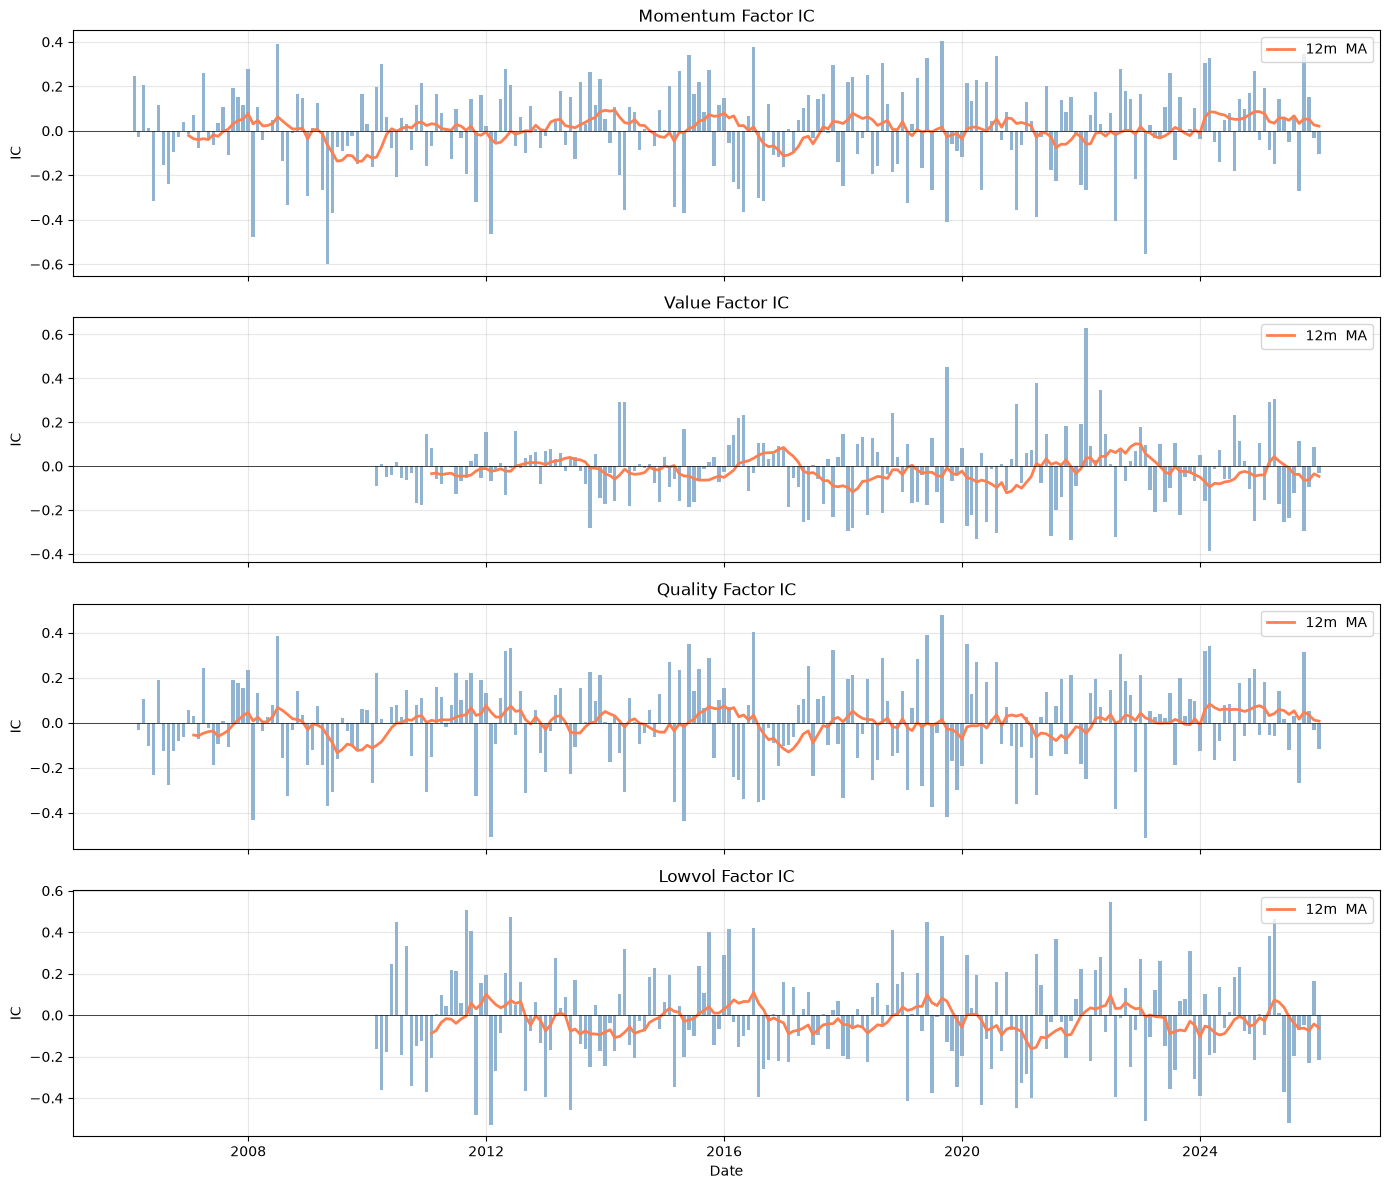

In [12]:
"""
==================================
Plot IC time series
==================================
"""
fig, axes = plt.subplots(4,1, figsize=(14,12), sharex = True)

for ax, (name, ic_series) in zip(axes, ic_results.items()):
    ax.bar(ic_series.index, ic_series.values, color='steelblue', alpha=0.6, width=20)
    ax.plot(ic_series.index, ic_series.rolling(12).mean(), color='coral', linewidth=2, label='12m  MA')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_ylabel('IC')
    ax.set_title(f'{name.capitalize()} Factor IC')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/ic_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

## Subperiod IC Stability (Walk-Forward)

A factor with positive full-sample IC could still be unreliable as it might have earned its entire IC in one lucky subperiod. Walk-forward IC analysis splits the sample into non-overlapping windows and computes the IC in each. A factor that's positive in most windows is robust; one that's positive in only one is fragile.

We'll do an overly-simplified form of walk-forward validation. It will tell us whether the factor's predictive power is a stable feature of the data or a consequence of a specific time period.

In [15]:
"""
==================================
Subperiod IC stability (walk-forward)
==================================
"""
windows = [(2006,2011), (2011,2016),(2016,2021),(2021,2026)]
subperiod_results = []

for name in factor_dict:
    ic = ic_results[name]
    for start, end in windows:
        mask = (ic.index.year >= start) & (ic.index.year < end)
        sub = ic[mask].dropna()
        if len(sub) < 12:
            continue
        subperiod_results.append({
            'factor': name,
            'period': f'{start}-{end}',
            'mean_ic': sub.mean(),
            'std_ic': sub.std(),
            'ir': sub.mean() / sub.std() * np.sqrt(12) if sub.std() > 0 else np.nan,
            'n': len(sub),
            'pct_positive': (sub > 0).mean()
        })

df_subperiod = pd.DataFrame(subperiod_results)

# Pivot for display
pivot_ic = df_subperiod.pivot(index='factor', columns='period', values='mean_ic')
pivot_ir = df_subperiod.pivot(index='factor', columns='period', values='ir')
pivot_pct = df_subperiod.pivot(index='factor', columns='period', values='pct_positive')

print("Mean IC by Subperiod\n")
display(pivot_ic.round(4))

print("\n Information Ration by Subperiod\n")
display(pivot_ir.round(3))

print("\n % Months with Positive IC\n")
display((pivot_pct * 100).round(1))

Mean IC by Subperiod



period,2006-2011,2011-2016,2016-2021,2021-2026
factor,,,,
lowvol,NaN,-0.0029,-0.0361,-0.0295
momentum,-0.0131,0.0276,-0.0079,0.0174
quality,-0.0287,0.0258,-0.0258,0.0183
value,NaN,-0.0179,-0.0331,-0.0095



 Information Ration by Subperiod



period,2006-2011,2011-2016,2016-2021,2021-2026
factor,,,,
lowvol,NaN,-0.043,-0.560,-0.420
momentum,-0.237,0.547,-0.130,0.325
quality,-0.593,0.461,-0.390,0.353
value,NaN,-0.576,-0.676,-0.170



 % Months with Positive IC



period,2006-2011,2011-2016,2016-2021,2021-2026
factor,,,,
lowvol,NaN,51.7,43.3,41.7
momentum,48.3,61.7,45.0,58.3
quality,47.5,63.3,43.3,60.0
value,NaN,40.0,46.7,48.3


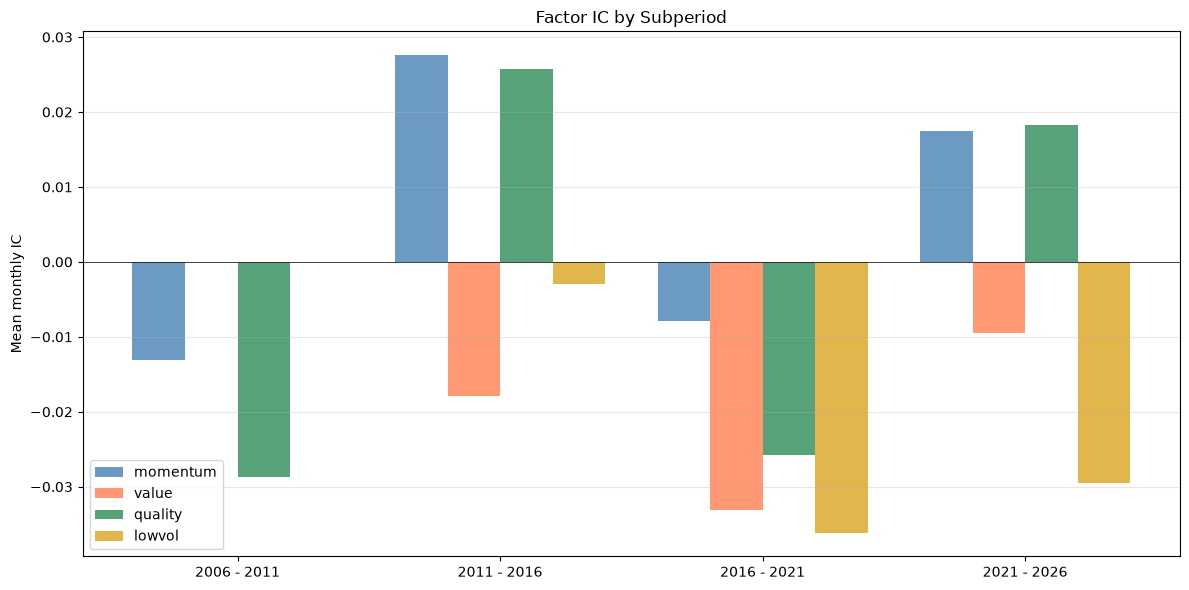

In [18]:
# Plot subperiod IC
fig,ax = plt.subplots(figsize=(12,6))
x = np.arange(len(windows))
width = 0.2
colors = ['steelblue', 'coral', 'seagreen', 'goldenrod']
for i, name in enumerate(factor_dict):
    vals = [pivot_ic.loc[name, f'{s}-{e}'] if f'{s}-{e}' in pivot_ic.columns else 0 for s, e in windows]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'{s} - {e}' for s,e in windows])
ax.set_ylabel('Mean monthly IC')
ax.set_title('Factor IC by Subperiod')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/ic_subperiod.png', dpi=150, bbox_inches='tight')
plt.show()

## Factor Decay

IC at 1-month tells you the signal exists. IC at longer horizons tells you how fast it dies. This sets your rebalance frequency. A factor with positive IC out to 12 months is slow-moving — you can trade it quarterly and capture most of what you need it to. A factor that's dead after 2 months is fast — you need monthly rebalancing, and transaction costs can play a role. 

Momentum is typically slow. Short-term reversal is fast. Low-vol is very slow. The decay curve tells you which is which.

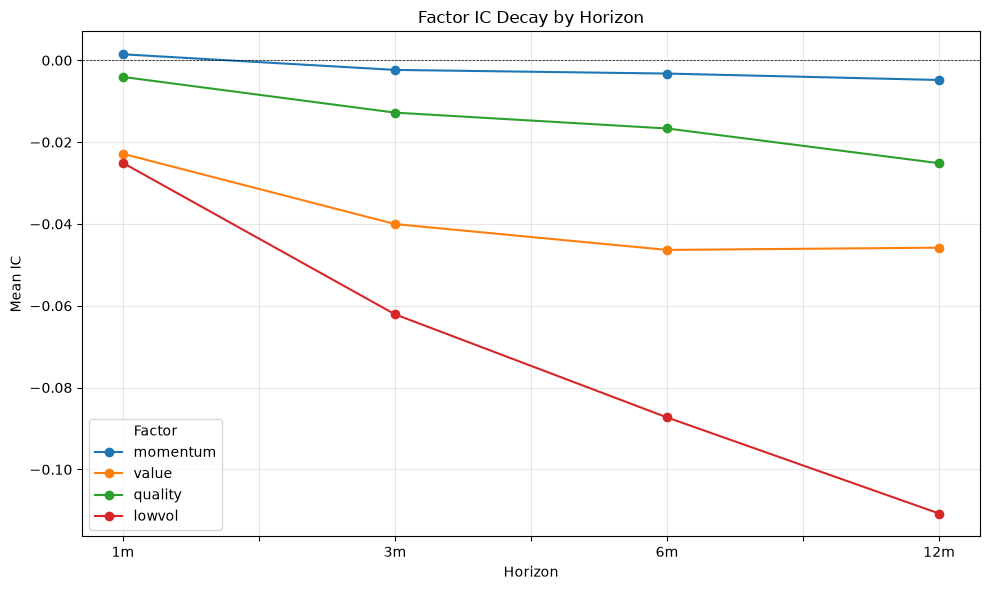

,1m,3m,6m,12m
momentum,0.0015,-0.0023,-0.0032,-0.0048
value,-0.0229,-0.0400,-0.0463,-0.0458
quality,-0.0041,-0.0128,-0.0167,-0.0251
lowvol,-0.0251,-0.0621,-0.0873,-0.1108


In [20]:
"""
==================================
IC decay at horizons 1, 3, 6, 12 months
==================================
"""
horizons = [1,3,6,12]
decay_results = {}

for name, df_f in factor_dict.items():
    decay_results[name] = []
    for h in horizons:
        # Forward returns at horizon h
        fwd_returns = df_returns.rolling(h).sum().shift(-h)
        ic_series = compute_monthly_ic(df_f, fwd_returns)
        decay_results[name].append(ic_series.mean())

df_decay = pd.DataFrame(decay_results, index=[f'{h}m' for h in horizons]).T

fig,ax = plt.subplots(figsize=(10,6))
df_decay.T.plot(ax=ax, marker='o')
ax.set_xlabel('Horizon')
ax.set_ylabel('Mean IC')
ax.set_title('Factor IC Decay by Horizon')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.grid(alpha=0.3)
ax.legend(title='Factor')

plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/ic_decay.png', dpi=150, bbox_inches='tight')
plt.show()

display(df_decay.round(4))

## Turnover via Rank Autocorrelation

A factor that re-ranks the universe every month will produce high turnover, and this contributes to lowering net returns after transaction costs.

**Rank autocorrelation** is the correlation between this month's factor rank vector and last month's. If the rank vector barely changes (autocorrelation $\approx$ 1), the portfolio barely trades. If it changes a lot (autocorrelation $\approx$ 0), turnover is high. In linear algebraic terms, the rank vector at $t$ is nearly parallel to the rank vector at $t-1$ for stable factors, and nearly orthogonal for unstable ones.

momentum: rank autocorr = 0.888, turnover proxy = 0.112
value: rank autocorr = 0.977, turnover proxy = 0.023
quality: rank autocorr = 0.898, turnover proxy = 0.102
lowvol: rank autocorr = 0.997, turnover proxy = 0.003


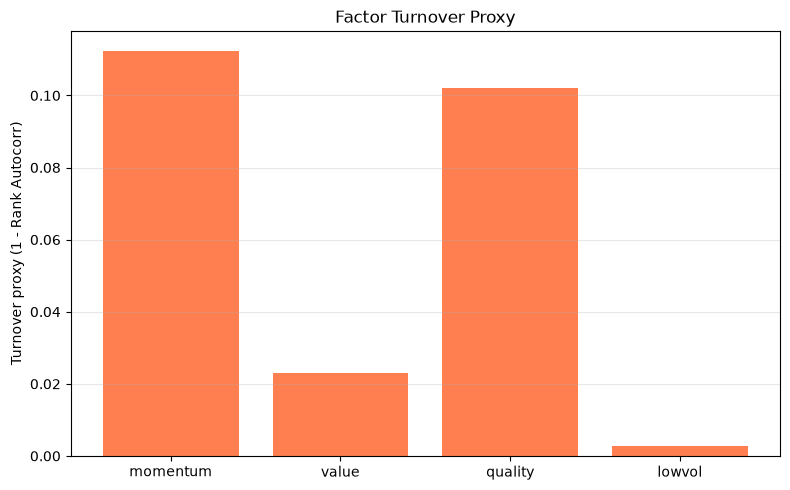

In [23]:
"""
==================================
Rank autocorrelation as turnover proxy
==================================
"""
def rank_autocorrelation(factor_df, lag=1):
    """Averages cross-sectional rank correlation between t and t-lag."""
    common_dates = factor_df.index[:-lag]
    autocorr = []
    for date in common_dates:
        f_now = factor_df.loc[date]
        f_lag = factor_df.loc[factor_df.index[factor_df.index.get_loc(date) + lag]]
        mask = f_now.notna() & f_lag.notna()
        if mask.sum() < 20:
            continue
        rho,_ = spearmanr(f_now[mask], f_lag[mask])
        autocorr.append(rho)
    return np.mean(autocorr)

turnover_proxy = {}
for name, df_f in factor_dict.items():
    rho = rank_autocorrelation(df_f, lag=1)
    turnover_proxy[name] = rho
    # Rough turnover estimate: 1 - rho
    print(f"{name}: rank autocorr = {rho:.3f}, turnover proxy = {1 - rho:.3f}")

fig,ax = plt.subplots(figsize=(8,5))
ax.bar(turnover_proxy.keys(), [1-v for v in turnover_proxy.values()], color='coral')
ax.set_ylabel('Turnover proxy (1 - Rank Autocorr)')
ax.set_title('Factor Turnover Proxy')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/turnover_proxy.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-Factor Correlations

The cross-factor correlation matrix is the **Gram matrix** of the factor vectors. If you stack the four factor vectors into a matrix $\mathbf{F} = [f_1, f_2, f_3, f_4]$, the Gram matrix is $\mathbf{G} = \mathbf{F}^\top \mathbf{F}$, where each entry $G_{ij} = \langle f_i, f_j \rangle$ is the inner product of two factor vectors. Since our factors are cross-sectional ranks centered at zero, these inner products are proportional to Pearson correlations — so the Gram matrix is literally the correlation matrix between factors.

High off-diagonal entries (near 1) mean two vectors are nearly collinear — they point in the same direction and carry redundant information. Low entries (near 0) mean they're nearly orthogonal — independent signal. If momentum and quality correlate at 0.86, combining them adds almost nothing; you're adding a vector to a near-parallel copy of itself. The ideal set of factors is a set of nearly orthogonal vectors, each with positive IC, so that a combined portfolio benefits from diversification rather than doubling down on the same bet.

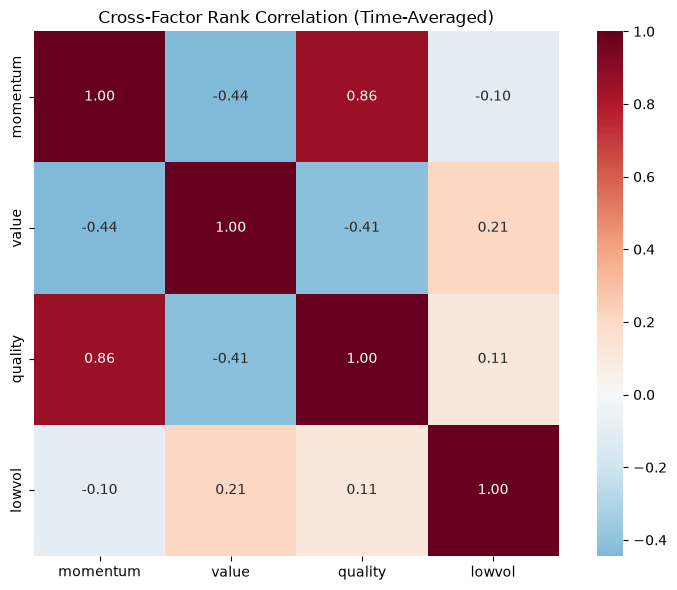

,momentum,value,quality,lowvol
momentum,1.000,-0.444,0.860,-0.104
value,-0.444,1.000,-0.412,0.210
quality,0.860,-0.412,1.000,0.109
lowvol,-0.104,0.210,0.109,1.000


In [26]:
"""
==================================
Cross-factor rank correlation (time-averaged)
==================================
"""
factor_names = list(factor_dict.keys())
corr_matrix = np.zeros((len(factor_names), len(factor_names)))

for i, name_i in enumerate(factor_names):
    for j, name_j in enumerate(factor_names):
        if i == j:
            corr_matrix[i,j] = 1.0
            continue
        df_i = factor_dict[name_i]
        df_j = factor_dict[name_j]
        common_dates = df_i.index.intersection(df_j.index)

        corrs = []
        for date in common_dates:
            a = df_i.loc[date]
            b = df_j.loc[date]
            mask = a.notna() & b.notna()
            if mask.sum() < 20:
                continue
            rho, _ = spearmanr(a[mask], b[mask])
            corrs.append(rho)
        corr_matrix[i,j] = np.mean(corrs)

df_corr = pd.DataFrame(corr_matrix, index=factor_names, columns=factor_names)

fig,ax = plt.subplots(figsize=(8,6))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Cross-Factor Rank Correlation (Time-Averaged)')

plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/factor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

display(df_corr.round(3))

In [27]:
"""
==================================
Save factor exposures and IC results
==================================
"""
for name, df_f in factor_dict.items():
    df_f.to_csv(f'../data/processed/factor_{name}.csv')

df_ic.to_csv('../data/processed/ic_monthly.csv')
df_decay.to_csv('../data/processed/ic_decay.csv')
df_corr.to_csv('../data/processed/factor_correlation.csv')

print("Saved factor exposures, IC series, decay, and correlation matrix.")

Saved factor exposures, IC series, decay, and correlation matrix.


## Conclusion

The diagnostics tell us that **momentum** is realistically the only signal worth carrying forward, and even it is modest. Its full-sample IC is $+0.006$ with an information ratio of $+0.11$ — positive, but weak. The encouraging part is consistency: momentum is the only factor with a positive mean IC in two of the four subperiods (2011–2016 at IR $0.55$ and 2021–2026 at IR $0.33$), and it decays slowly, staying near zero out to the 12-month horizon. That slow decay, combined with a moderate turnover proxy of $0.11$, means a monthly or quarterly rebalance captures most of the edge. Momentum is not a strong signal in this universe, but it is a *real* one.

The other three factors fail, and the **why** is more instructive than the failure:

- **Value** (IC $-0.022$, IR $-0.48$, negative in every subperiod): our proxy is inverse 60-month return, intended to capture mean reversion of "cheap" stocks. Instead it loaded on long-term *momentum continuation* — five-year winners kept winning, so the inverted signal predicted negative returns. A price-only value proxy cannot separate cheapness from drift; it needs fundamentals (book-to-market, earnings yield).
- **Quality** (IC $-0.003$, IR $-0.04$, statistically zero): the 12-month Sharpe proxy is dominated by the direction of recent returns, which is why it correlates **0.86** with momentum. It is not an independent signal — it is momentum with extra noise. Adding it to a portfolio doubles down on the same bet rather than diversifying.
- **Low-volatility** (IC $-0.026$, IR $-0.38$, decaying to $-0.11$ at 12m): low-vol names underperformed high-vol names in this window, the opposite of the low-vol anomaly. The inverse-60m-vol proxy is too crude to isolate the anomaly, and the period itself was risk-on. Its one virtue is extreme stability (turnover proxy $0.003$), but a stable negative-IC signal is just a reliably bad signal.

The **Gram matrix** confirms the structural problem. Momentum and quality are near-collinear ($0.86$); value is anti-correlated with both ($-0.44$, $-0.41$) because it is inverse-momentum at a different horizon; only low-vol is close to orthogonal to the rest ($\approx 0.1$). So of four factors, we effectively have one directional bet (momentum/quality), its mirror image (value), and one orthogonal but useless signal (low-vol). There is no diversification to harvest from this set.

**What carries forward:** momentum is the candidate signal for portfolio construction in later notebooks. The value, quality, and low-vol proxies should be discarded or re-engineered with genuine fundamental and risk data before they can contribute. The methodology — IC, walk-forward stability, decay, turnover, and the correlation structure — is sound; the inputs were not.